# Import Environment variables

In [1]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.ipynb

Found bucket: id=rw-migration-aou-rw-f7a4d148, bucketName=rw-migration-aou-rw-f7a4d148
-> Assigned migration variables (ID: rw-migration-aou-rw-f7a4d148)
Found bucket: id=temporary-workspace-bucket, bucketName=temporary-workspace-bucket-wb-perky-cabbage-8342
Found bucket: id=workspace-bucket, bucketName=workspace-bucket-wb-perky-cabbage-8342
✅ Successfully identified latest dataset: wb-silky-artichoke-2408.C2024Q3R9

Variables extracted:
GOOGLE_CLOUD_PROJECT: wb-perky-cabbage-8342
WORKSPACE_BUCKET: gs://workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_TEMP_BUCKET: gs://temporary-workspace-bucket-wb-perky-cabbage-8342
WORKSPACE_CDR: wb-silky-artichoke-2408.C2024Q3R9
bucket_aou_tutorial: NOT FOUND
bucket_id_aou_tutorial: NOT FOUND
bucket_migrated: gs://rw-migration-aou-rw-f7a4d148
bucket_id_migrated: rw-migration-aou-rw-f7a4d148

✅ Saved to /home/jupyter/.bashrc
C2024Q3R9 BQ_DATASET
Multi-trait-GWAS-in-admixed-populations GIT_REPO
dataset_test2 BQ_DATASET
prep_C2024Q3R9 BQ_DATASET
rw-mig

In [2]:
%run /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.ipynb

WORKSPACE_CDR = wb-silky-artichoke-2408.C2024Q3R9
WORKSPACE_BUCKET = gs://workspace-bucket-wb-perky-cabbage-8342
GOOGLE_PROJECT = wb-perky-cabbage-8342
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables_p2.R
Done! 10 variables saved to: /home/jupyter/repos/Multi-trait-GWAS-in-admixed-populations/notebooks/Setting_Env_Variables.sas


# Librairy

In [3]:
import os
import numpy as np
import pandas as pd

# Data's import

## PRS 298, 305 et 311

In [4]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "df_all_prs_298_305_311.csv"

df_prs = pd.read_csv(my_bucket +'/Data/'+ name_of_file_in_bucket, sep=',', low_memory=False)

## Clinical data

In [5]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "df_bc_ko_at_inclusion_223k_nb_BC_WITHIN_5Y_GeneticAncestry_biopsy_FamilyHistory_LastSelection.tsv"

df = pd.read_csv(my_bucket +'/Data/'+ name_of_file_in_bucket, sep=',', low_memory=False)

In [6]:
df.drop(columns=['gender','date_of_birth','ethnicity','self_reported_category','time_category','delay_years',
                 'first_any_biopsy_date','days_inclusion_to_biopsy', 'days_biopsy_to_cancer',
                 'first_survey_date', 'last_survey_date','days_last_survey_to_first_survey', 'days_inclusion_to_first_survey',
                 'days_inclusion_to_last_survey', 'days_has_bc_to_first_survey','days_has_bc_to_last_survey',
                 'date_1_of_biopsy_19081_19086', 'date_2_of_biopsy_19081_19086', 'date_3_of_biopsy_19081_19086',
                 'has_biopsy_19081_19086',
                 'date_1_of_biopsy_19100_19103', 'date_2_of_biopsy_19100_19103', 'date_3_of_biopsy_19100_19103',
                 'has_biopsy_19100_19103',
                 'date_1_of_biopsy_19120_19125_19126', 'date_2_of_biopsy_19120_19125_19126', 'date_3_of_biopsy_19120_19125_19126',
                 'has_biopsy_19120_19125_19126',
                 'Daughter', 'Mother', 'Sibling',
                 'statut_parente'], inplace=True)

In [7]:
df.columns

Index(['person_id', 'inclusion_date', 'first_breast_cancer_date', 'delay_days',
       'age_at_inclusion', 'has_bc', 'eur_rye', 'eas_rye', 'amr_rye',
       'afr_rye', 'sas_rye', 'mid_rye', 'dominant_origin', 'ancestry_80',
       'biopsy_result', 'age_category', 'race_us_bcsc', 'race_us_bcsc_detail',
       'breast_cancer_family_history_first_degree'],
      dtype='object')

### Selection des femmes européennes

In [8]:
df[df['race_us_bcsc_detail'] == 'eur_rye'].value_counts('has_bc')

has_bc
0    73120
1      464
Name: count, dtype: int64

In [9]:
df_eur = df[df['race_us_bcsc_detail'] == 'eur_rye'].copy()

# Data set merged

In [10]:
df_models = pd.merge(df_eur, df_prs, left_on='person_id', right_on='index', how='left')

# Split de la cohorte européenne

In [11]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "train_ids_eur.csv"

train_ids_eur = pd.read_csv(my_bucket +'/Data/'+ name_of_file_in_bucket, sep=',', low_memory=False)

In [12]:
# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

name_of_file_in_bucket = "test_ids_eur.csv"

test_ids_eur = pd.read_csv(my_bucket +'/Data/'+ name_of_file_in_bucket, sep=',', low_memory=False)

# Evaluation de performance des PRS

## Définition de la fonction

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import auc, roc_curve


def bootstrap_auc(y_true_ser, y_scores_ser, n_bootstraps=1000, rng_seed=42):
    """Calcule l'intervalle de confiance à 95% de l'AUC-ROC par bootstrap."""
    bootstrapped_scores = []
    rng = np.random.RandomState(rng_seed)
    y_true_arr = np.array(y_true_ser)
    y_scores_arr = np.array(y_scores_ser)

    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_scores_arr), len(y_scores_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
        score = auc(*roc_curve(y_true_arr[indices], y_scores_arr[indices])[:2])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)
    return sorted_scores[int(0.025 * len(sorted_scores))], sorted_scores[
        int(0.975 * len(sorted_scores))
    ]


def evaluate_and_plot_model(
    df_data,
    test_ids,
    score_col,
    target_col="has_bc",
    alpha_val=0.0,
    id_col="person_id",
    model_name="BCSC v2",
    quantiles=None,
    labels=None,
    ref_quantile_idx=2,  # Par défaut Q3 (index 2 dans [Q1, Q2, Q3, Q4, Q5])
    figsize=(16, 6),
):
    """Évalue et trace les graphiques de discrimination (ROC) et de calibration (Incidence/OR)

    sur un jeu de test indépendant.
    """
    if quantiles is None:
        quantiles = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
    if labels is None:
        labels = [
            "Q1 (<20%)",
            "Q2 (20-40%)",
            "Q3 (40-60%)",
            "Q4 (60-80%)",
            "Q5 (>80%)",
        ]

    # 1. Sélection et nettoyage du Jeu de Test (75%)
    ids_to_match = (
        test_ids.values if hasattr(test_ids, "values") else list(test_ids)
    )
    df_test = df_data[df_data[id_col].isin(ids_to_match)].copy()
    df_eval = df_test.dropna(subset=[target_col, score_col]).copy()

    y_true = df_eval[target_col]
    p_brut = df_eval[score_col]

    # 2. Application de la recalibration d'intercept (alpha)
    p_clipped = np.clip(p_brut, 1e-6, 1.0 - 1e-6)
    logit_p = np.log(p_clipped / (1.0 - p_clipped))
    logit_p_recalib = logit_p + alpha_val
    p_recalib = 1.0 / (1.0 + np.exp(-logit_p_recalib))

    # Nom dynamique de la colonne recalibrée (ex: score_mammorisk_recalib)
    recalib_col_name = f"{score_col}_recalib"
    df_eval[recalib_col_name] = p_recalib

    # 3. Métriques ROC et AUC
    fpr, tpr, _ = roc_curve(y_true, p_recalib)
    roc_auc = auc(fpr, tpr)
    ci_lower, ci_upper = bootstrap_auc(y_true, p_recalib)

    # 4. Métriques O/E (Calibration globale)
    observed_cases = int(y_true.sum())
    expected_brut = float(p_brut.sum())
    expected_recalib = float(p_recalib.sum())

    oe_brut = observed_cases / expected_brut if expected_brut > 0 else np.nan
    oe_recalib = (
        observed_cases / expected_recalib if expected_recalib > 0 else np.nan
    )

    # 5. Découpage en Quantiles & Calculs par groupe
    df_eval["risk_group"] = pd.qcut(
        df_eval[recalib_col_name],
        q=quantiles,
        labels=labels,
        duplicates="drop",
    )

    # A. Incidence réelle (%)
    incidence = df_eval.groupby("risk_group", observed=False)[target_col].agg(
        ["mean", "count"]
    )
    incidence["pct"] = incidence["mean"] * 100
    incidence = incidence.reindex(labels)

    # B. Risque moyen prédit réétalonné (%)
    pred_risk = df_eval.groupby("risk_group", observed=False)[
        recalib_col_name
    ].mean()
    pred_risk_pct = (pred_risk * 100).reindex(labels)

    # C. Odds Ratios par régression logistique
    dummies = pd.get_dummies(df_eval["risk_group"], drop_first=False)

    ref_col = labels[ref_quantile_idx]
    if ref_col not in dummies.columns:
        ref_col = dummies.columns[len(dummies.columns) // 2]

    X = dummies.drop(columns=[ref_col]).astype(int)
    X = sm.add_constant(X)

    logit_mod = sm.Logit(y_true, X).fit(disp=False)
    conf = logit_mod.conf_int()

    or_df = pd.DataFrame(
        {
            "OR": np.exp(logit_mod.params),
            "lower": np.exp(conf[0]),
            "upper": np.exp(conf[1]),
        }
    )
    or_df.loc["const"] = [1.0, 1.0, 1.0]
    or_df.index = [c if c != "const" else ref_col for c in or_df.index]
    or_df = or_df.reindex(labels)

    # 6. Tracé de la Figure à 2 Panneaux
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # --- Subplot 1 : ROC & Cartouche O/E ---
    axes[0].plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=(
            f"{model_name} (AUC = {roc_auc:.3f} [IC 95% :"
            f" {ci_lower:.3f}-{ci_upper:.3f}])"
        ),
    )
    axes[0].plot(
        [0, 1],
        [0, 1],
        color="navy",
        lw=1.5,
        linestyle="--",
        label="Hasard (AUC = 0.50)",
    )
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("1 - Spécificité (Taux Faux Positifs)", fontsize=10)
    axes[0].set_ylabel("Sensibilité (Taux Vrais Positifs)", fontsize=10)
    axes[0].set_title(
        f"Courbe ROC - Modèle {model_name} (Jeu Test N={len(df_eval)})",
        fontsize=11,
        fontweight="bold",
    )
    axes[0].legend(loc="lower right")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    text_str = (
        r"$\mathbf{Calibration\ globale\ (Test\ 75\%):}$"
        "\n"
        rf"• $\mathbf{{Cas\ observés\ (O)\ :}}$ {observed_cases}"
        "\n\n"
        r"$\mathbf{1.\ Modèle\ Brut:}$"
        "\n"
        rf"• Cas attendus (E) : {expected_brut:.1f}"
        "\n"
        rf"• $\mathbf{{Ratio\ O/E\ :}}$ {oe_brut:.3f}"
        "\n\n"
        rf"$\mathbf{{2.\ Modèle\ Recalibré\ (\alpha = {alpha_val:.4f}):}}$"
        "\n"
        rf"• Cas attendus (E) : {expected_recalib:.1f}"
        "\n"
        rf"• $\mathbf{{Ratio\ O/E\ :}}$ {oe_recalib:.3f}"
    )

    axes[0].text(
        0.04,
        0.96,
        text_str,
        transform=axes[0].transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9,
        ),
    )

    # --- Subplot 2 : Barres d'Incidence/Risque Prédit + OR ---
    x_pos = np.arange(len(labels))

    axes[1].bar(
        x_pos - 0.15,
        incidence["pct"],
        width=0.3,
        alpha=0.6,
        color="skyblue",
        edgecolor="navy",
        label="Incidence réelle (%)",
    )

    axes[1].bar(
        x_pos + 0.15,
        pred_risk_pct,
        width=0.3,
        alpha=0.6,
        color="orange",
        edgecolor="darkorange",
        label="Risque prédit réétalonné (%)",
    )

    axes[1].set_xlabel("Quantiles de risque", fontsize=10)
    axes[1].set_ylabel(
        "Pourcentage (%)", fontsize=10, color="navy", fontweight="bold"
    )
    axes[1].tick_params(axis="y", labelcolor="navy")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(labels, rotation=30)
    axes[1].grid(True, linestyle=":", alpha=0.4)

    ax2 = axes[1].twinx()
    valid_or = or_df.dropna(subset=["OR"])
    valid_x = [labels.index(idx) for idx in valid_or.index if idx in labels]

    line_or = ax2.errorbar(
        valid_x,
        valid_or["OR"],
        yerr=[
            valid_or["OR"] - valid_or["lower"],
            valid_or["upper"] - valid_or["OR"],
        ],
        fmt="o-",
        color="darkred",
        ecolor="crimson",
        elinewidth=1.8,
        capsize=4,
        markersize=6,
        label="Odds Ratio (IC 95%)",
    )

    ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.7)
    ax2.set_ylabel(
        f"Odds Ratio (OR) vs Quantile Médian ({ref_col})",
        fontsize=10,
        color="darkred",
        fontweight="bold",
    )
    ax2.tick_params(axis="y", labelcolor="darkred")

    lines_1, labels_1 = axes[1].get_legend_handles_labels()
    axes[1].legend(
        lines_1 + [line_or],
        labels_1 + ["Odds Ratio (IC 95%)"],
        loc="upper left",
        frameon=True,
        fontsize=8.5,
    )

    axes[1].set_title(
        f"Incidence, Risque prédit et Odds Ratios par quantile ({model_name})",
        fontsize=11,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

    # Dictionnaire des métriques
    metrics = {
        "AUC": roc_auc,
        "AUC_CI": (ci_lower, ci_upper),
        "OE_brut": oe_brut,
        "OE_recalib": oe_recalib,
        "alpha": alpha_val,
        "N_test": len(df_eval),
    }

    # La fonction retourne DEUX objets : le dictionnaire et le DataFrame
    return metrics, df_eval

## PRS 298

### Calcul du alpha recalibré sur le train set (25%)


==================== Traitement de : prs_298 ====================
Paramètres appris sur le Train (25%) pour prs_298 :
  • Intercept (alpha) : -5.1219
  • Pente (beta)      : 0.4556


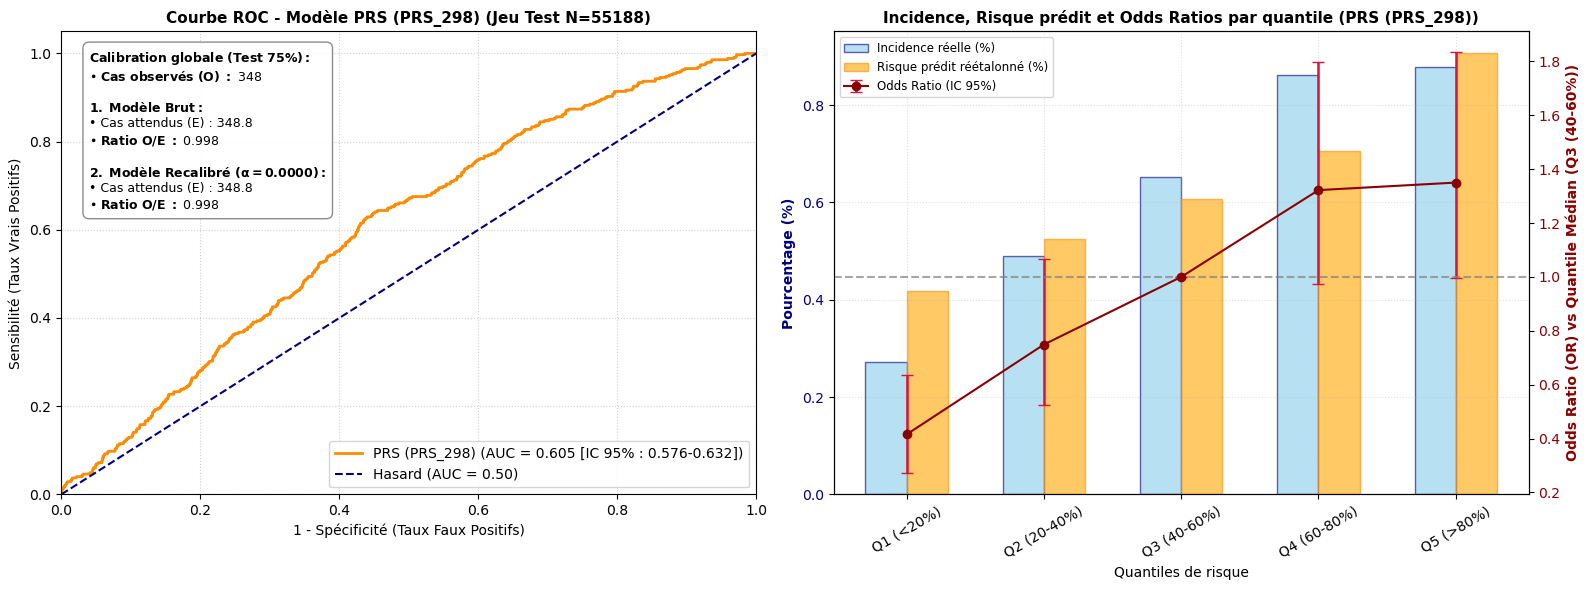


==================== Traitement de : prs_305 ====================
Paramètres appris sur le Train (25%) pour prs_305 :
  • Intercept (alpha) : -5.1230
  • Pente (beta)      : 0.4576


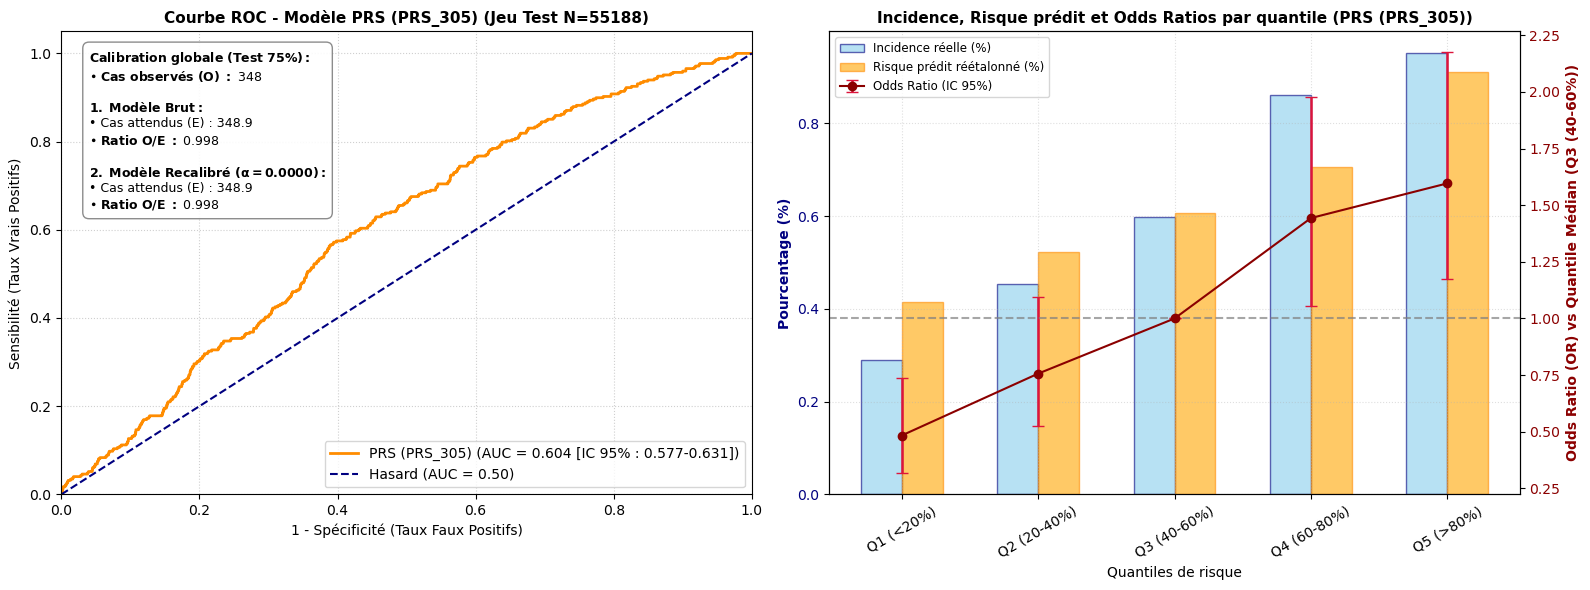


==================== Traitement de : prs_311 ====================
Paramètres appris sur le Train (25%) pour prs_311 :
  • Intercept (alpha) : -5.1298
  • Pente (beta)      : 0.4414


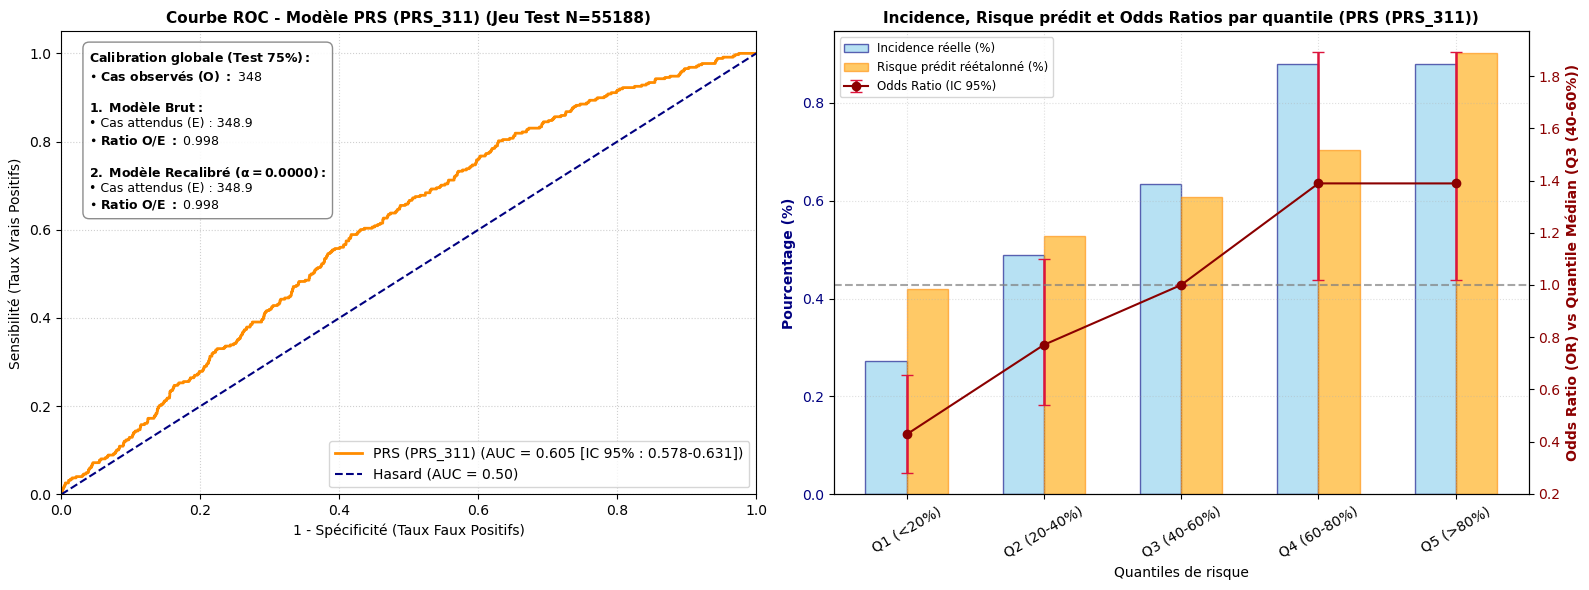


 Traitement terminé pour tous les PRS ! Les résultats sont prêts.


In [14]:
import statsmodels.api as sm

# 1. Estimation de alpha (intercept) et beta (pente) sur le Train (25%)
df_train = df_models[df_models["person_id"].isin(train_ids_eur["person_id"])].copy()
df_train_clean = df_train.dropna(subset=["has_bc", "prs_298"]).copy()

y_train = df_train_clean["has_bc"]
X_train = sm.add_constant(df_train_clean["prs_298"])

model_prs = sm.Logit(y_train, X_train).fit(disp=False)

alpha_prs = model_prs.params.iloc[0]
beta_prs = model_prs.params.iloc[1]

print(f"Paramètres PRS appris sur le Train (25%) :")
print(f"• Intercept (alpha) : {alpha_prs:.4f}")
print(f"• Pente (beta)      : {beta_prs:.4f}")

# 2. Transformation du score en probabilités réétalonnées sur l'ENSEMBLE du jeu de données
# (pour alimentation de la fonction d'évaluation)
df_models["prs_prob_recalib"] = 1.0 / (
    1.0 + np.exp(-(alpha_prs + beta_prs * df_models["prs_298"]))
)

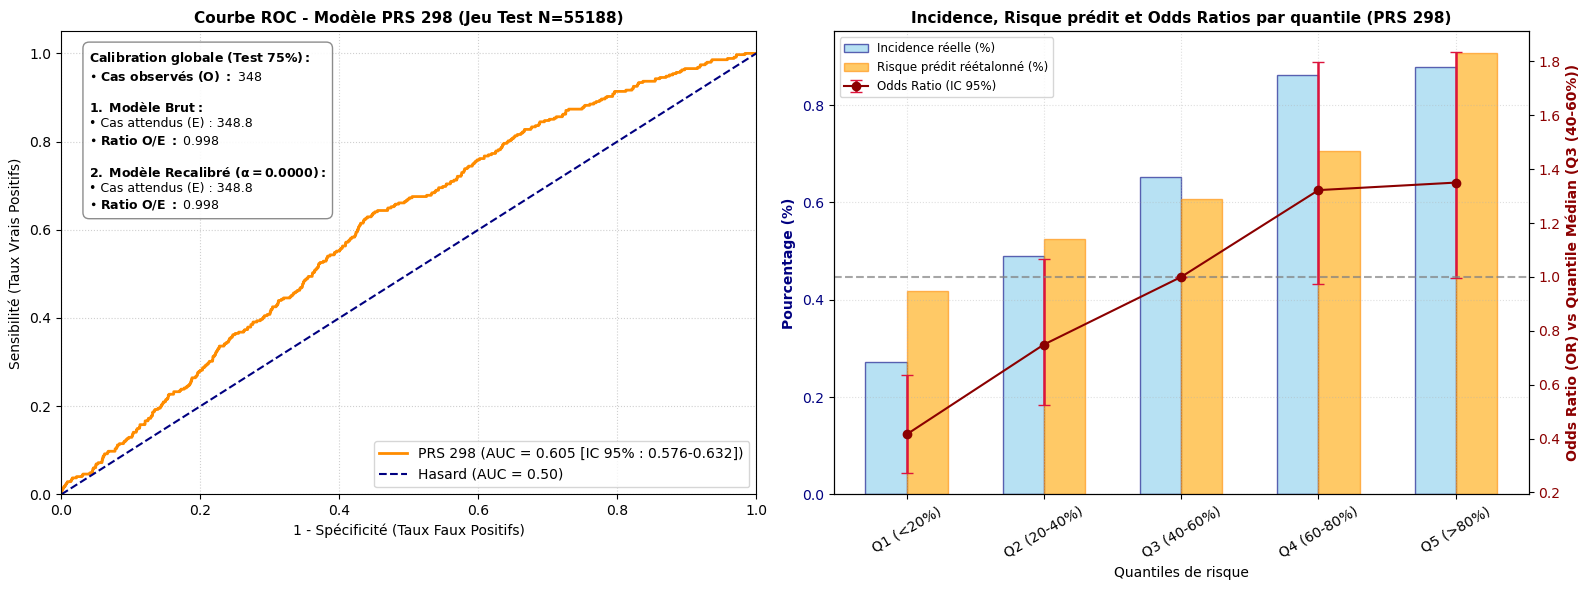

In [17]:
# 3. Évaluation et graphique sur le jeu Test (75%)
metrics_prs298, df_prs298_eval = evaluate_and_plot_model(
    df_data=df_models,
    test_ids=test_ids_eur["person_id"],
    score_col="prs_298_prob_recalib",
    target_col="has_bc",
    alpha_val=0.0,  # Déjà réétalonné via alpha_prs et beta_prs
    id_col="person_id",
    model_name="PRS 298",
)

## PRS 305

## PRS 311